Первые 5 строк датасета:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5       

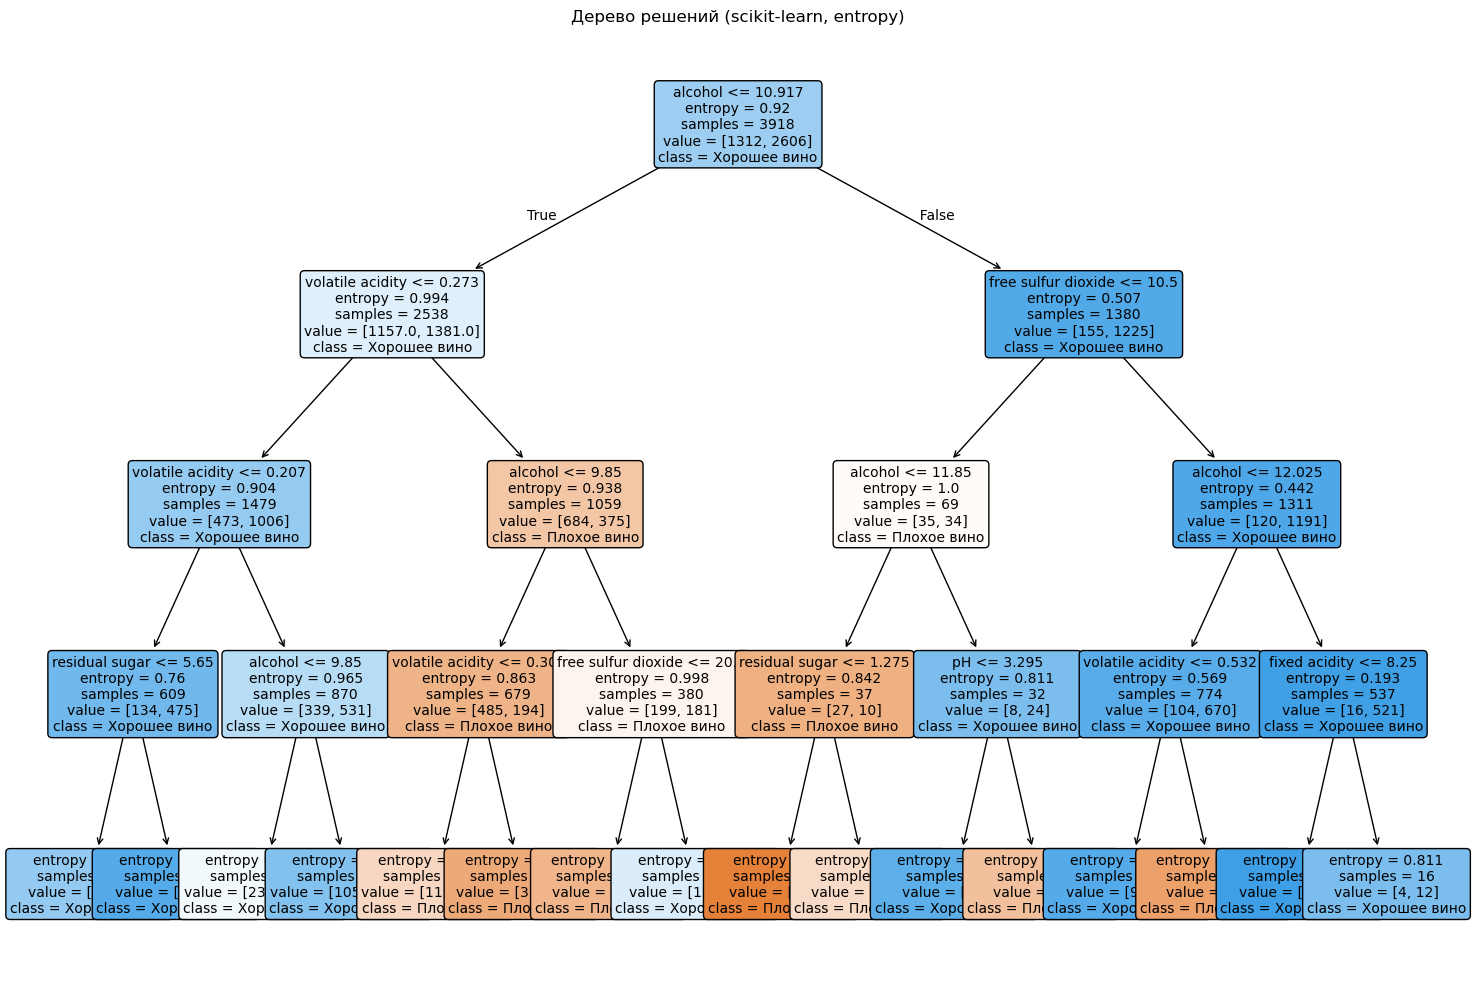


Важность признаков (scikit-learn):
  fixed acidity: 0.0099
  volatile acidity: 0.3023
  citric acid: 0.0000
  residual sugar: 0.0374
  chlorides: 0.0000
  free sulfur dioxide: 0.0782
  total sulfur dioxide: 0.0000
  density: 0.0000
  pH: 0.0051
  sulphates: 0.0000
  alcohol: 0.5671

Сравнение моделей
Модель C4.5 (ручная реализация):
  - Точность: 0.6663
  - Правильно классифицировано: 653/980
  - Ошибок: 327

Scikit-learn (entropy):
  - Точность: 0.7531
  - Правильно классифицировано: 738/980
  - Ошибок: 242


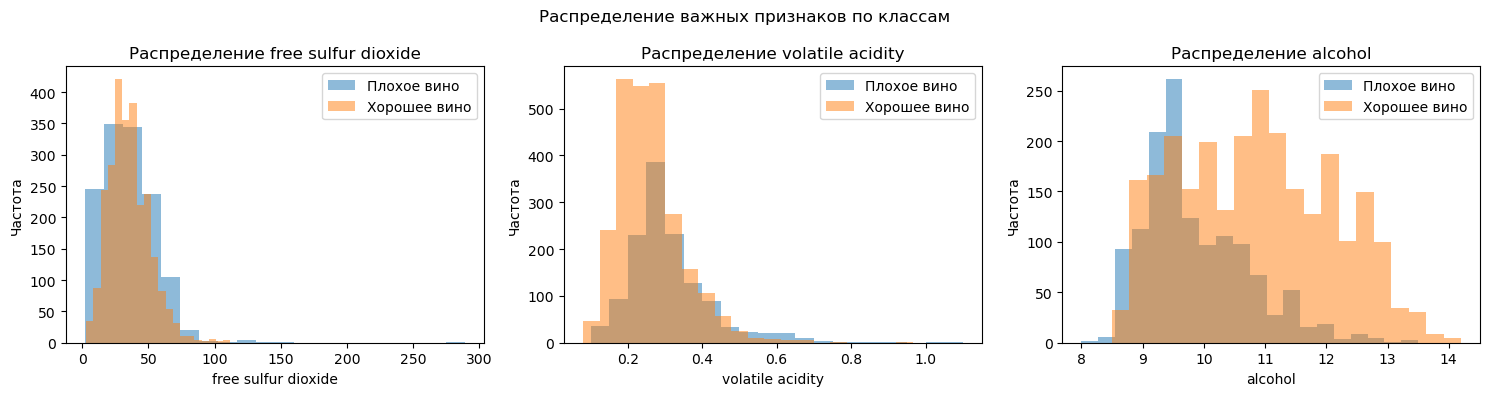


Анализ пороговых значений для самых важных признаков

Признак: free sulfur dioxide
  - Порог C4.5 (ручной): 115.2500
  - Gain Ratio: 0.1496
  - Образцов слева: 3911
  - Образцов справа: 7
  - Доля хороших слева: 0.666
  - Доля хороших справа: 0.000

Признак: volatile acidity
  - Порог C4.5 (ручной): 0.9850
  - Gain Ratio: 0.1276
  - Образцов слева: 3916
  - Образцов справа: 2
  - Доля хороших слева: 0.665
  - Доля хороших справа: 0.000

Признак: alcohol
  - Порог C4.5 (ручной): 8.4500
  - Gain Ratio: 0.1429
  - Образцов слева: 5
  - Образцов справа: 3913
  - Доля хороших слева: 0.000
  - Доля хороших справа: 0.666


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from collections import Counter
import math

# Загрузка и подготовка данных
df = pd.read_csv('winequality.csv', sep=';')
print("Первые 5 строк датасета:")
print(df.head())

print(f"\nРазмер датасета: {df.shape}")
print(f"Названия колонок: {df.columns.tolist()}")
print(f"Уникальные значения качества: {sorted(df['quality'].unique())}")

# Для простоты преобразуем задачу в бинарную классификацию
df['quality_binary'] = np.where(df['quality'] >= 6, 1, 0)

features = df.columns[:-2].tolist()  # Все признаки кроме quality и quality_binary
X = df[features].values  
y = df['quality_binary'].values  

print(f"\nПризнаки: {features}")
print(f"Распределение классов: {np.bincount(y)}")
print(f"Доля хороших вин: {np.mean(y):.2f}")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nРазмеры выборок:")
print(f"Обучающая: {X_train.shape}, Тестовая: {X_test.shape}")

x1_train = X_train[y_train == 1]  # хорошие вина
x0_train = X_train[y_train == 0]  # плохие вина
print(f"Количество хороших вин в обучении: {len(x1_train)}")
print(f"Количество плохих вин в обучении: {len(x0_train)}")

# Узел дерева C4.5
class NodeC45:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, 
                 children=None, feature_value=None, value=None, is_leaf=False,
                 split_info=0, gain_ratio=0):  # Добавлены параметры split_info и gain_ratio
        self.feature_index = feature_index      # Индекс признака для разбиения
        self.threshold = threshold              # Пороговое значение (для непрерывных признаков)
        self.feature_value = feature_value      # Значение признака (для категориальных)
        self.left = left                        # Левый потомок (для бинарного разбиения)
        self.right = right                      # Правый потомок (для бинарного разбиения)
        self.children = children                # Дети (для категориальных признаков)
        self.value = value                      # Значение в листовом узле
        self.is_leaf = is_leaf                  # Флаг листового узла
        self.split_info = split_info            # Информация разбиения
        self.gain_ratio = gain_ratio            # Коэффициент усиления

# Класс для дерева решений C4.5
class C45DecisionTree:
    def __init__(self, max_depth=3, min_samples_split=2, min_gain_ratio=0.01):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_gain_ratio = min_gain_ratio
        self.root = None
        self.feature_names = None
    
    # Вычисление энтропии
    def calculate_entropy(self, y):
        if len(y) == 0:
            return 0
        # Подсчет вероятностей каждого класса
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        # Добавим небольшую константу для избежания log2(0)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy
    
    # Вычисление информации разбиения (Split Info)
    def calculate_split_info(self, splits):
        total = sum(len(split) for split in splits)
        if total == 0:
            return 0
        split_info = 0
        for split in splits:
            if len(split) > 0:
                ratio = len(split) / total
                split_info -= ratio * np.log2(ratio + 1e-10)
        return split_info
    
    # Поиск лучшего порога для непрерывного признака
    def find_best_threshold(self, feature_values, y):
        best_gain_ratio = -1
        best_threshold = None
        best_left_indices = None
        best_right_indices = None
        best_split_info = 0
        
        # Сортируем уникальные значения
        sorted_values = np.unique(feature_values)
        if len(sorted_values) <= 1:
            return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
        
        # Проверяем возможные пороги (середины между соседними значениями)
        for i in range(len(sorted_values) - 1):
            threshold = (sorted_values[i] + sorted_values[i + 1]) / 2
            
            left_indices = feature_values <= threshold
            right_indices = feature_values > threshold
            
            if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
                continue
            
            # Вычисляем энтропию
            entropy_parent = self.calculate_entropy(y)
            entropy_left = self.calculate_entropy(y[left_indices])
            entropy_right = self.calculate_entropy(y[right_indices])
            
            # Информационный прирост
            n_left = np.sum(left_indices)
            n_right = np.sum(right_indices)
            total_samples = n_left + n_right
            
            info_gain = entropy_parent - (n_left/total_samples * entropy_left + n_right/total_samples * entropy_right)
            
            # Информация разбиения
            split_info = self.calculate_split_info([y[left_indices], y[right_indices]])
            
            # Коэффициент усиления (Gain Ratio)
            if split_info > 0:
                gain_ratio = info_gain / split_info
            else:
                gain_ratio = 0
            
            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_threshold = threshold
                best_left_indices = left_indices
                best_right_indices = right_indices
                best_split_info = split_info
        
        return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
    
    # Поиск лучшего разбиения для всех признаков
    def find_best_split(self, X, y):
        best_gain_ratio = -1
        best_split = {}
        n_samples, n_features = X.shape
        
        # Если выборка слишком мала для разбиения
        if n_samples < self.min_samples_split:
            return best_split
        
        current_entropy = self.calculate_entropy(y)
        print(f"  Текущая энтропия: {current_entropy:.4f}")
        
        # Перебор всех признаков
        for feature_index in range(n_features):
            feature_name = features[feature_index] if features else f"Feature_{feature_index}"
            print(f"  Признак {feature_name}:", end=" ")
            
            feature_values = X[:, feature_index]
            
            # Для C4.5 считаем все признаки непрерывными (в данном датасете все признаки числовые)
            gain_ratio, threshold, left_indices, right_indices, split_info = self.find_best_threshold(feature_values, y)
            
            if gain_ratio > best_gain_ratio and threshold is not None:
                best_gain_ratio = gain_ratio
                best_split = {
                    'feature_index': feature_index,
                    'threshold': threshold,
                    'left_indices': left_indices,
                    'right_indices': right_indices,
                    'gain_ratio': gain_ratio,
                    'split_info': split_info,
                    'info_gain': current_entropy - (np.sum(left_indices)/n_samples * self.calculate_entropy(y[left_indices]) + 
                                                   np.sum(right_indices)/n_samples * self.calculate_entropy(y[right_indices])),
                    'is_categorical': False
                }
        
        if best_split:
            feature_name = features[best_split['feature_index']] if features else f"Feature_{best_split['feature_index']}"
            print(f"  Лучшее разбиение: Признак '{feature_name}', "
                  f"Порог={best_split['threshold']:.4f}, Gain Ratio={best_split['gain_ratio']:.4f}, "
                  f"Split Info={best_split['split_info']:.4f}")
        
        return best_split
    
    # Рекурсивное построение дерева
    def build_tree(self, X, y, depth=0):
        if (depth >= self.max_depth or 
            len(y) < self.min_samples_split or 
            len(np.unique(y)) == 1 or
            self.calculate_entropy(y) < 0.01):  # Изменено с == 0 на < 0.01
            # Создание листового узла с наиболее частым классом
            if len(y) == 0:
                value = 0
            else:
                value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            leaf_entropy = self.calculate_entropy(y)
            print(f"Создан лист на глубине {depth}: класс={value}, образцов={len(y)}, энтропия={leaf_entropy:.4f}")
            return NodeC45(value=value, is_leaf=True)
        
        # Поиск лучшего разбиения
        print(f"\nУровень {depth}: {len(y)} образцов")
        best_split = self.find_best_split(X, y)
        
        # Проверяем, достаточно ли Gain Ratio
        if not best_split or best_split['gain_ratio'] < self.min_gain_ratio:
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            leaf_entropy = self.calculate_entropy(y)
            print(f"Недостаточный Gain Ratio, создан лист: класс={value}, энтропия={leaf_entropy:.4f}")
            return NodeC45(value=value, is_leaf=True)
        
        # Создаем узел
        node = NodeC45(
            feature_index=best_split['feature_index'],
            threshold=best_split['threshold'],
            gain_ratio=best_split['gain_ratio'],
            split_info=best_split['split_info']
        )
        
        # Рекурсивное построение левого и правого поддеревьев
        feature_name = features[best_split['feature_index']] if features else f"Feature_{best_split['feature_index']}"
        print(f"  Создано разбиение по признаку {feature_name} <= {best_split['threshold']:.4f}")
        print(f"  Левая ветвь: {np.sum(best_split['left_indices'])} образцов")
        print(f"  Правая ветвь: {np.sum(best_split['right_indices'])} образцов")
        
        left_subtree = self.build_tree(
            X[best_split['left_indices']], 
            y[best_split['left_indices']], 
            depth + 1
        )
        
        right_subtree = self.build_tree(
            X[best_split['right_indices']], 
            y[best_split['right_indices']], 
            depth + 1
        )
        
        node.left = left_subtree
        node.right = right_subtree
        
        return node
    
    # Обучение дерева
    def fit(self, X, y, feature_names=None):
        if feature_names is not None:
            self.feature_names = feature_names
        else:
            self.feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
        self.root = self.build_tree(X, y)
    
    # Рекурсивное предсказание для одного образца
    def predict_sample(self, x, node):
        if node.is_leaf:
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    # Предсказание для всего набора данных
    def predict(self, X):
        predictions = []
        for x in X:
            predictions.append(self.predict_sample(x, self.root))
        return np.array(predictions)
    
    # Визуализация дерева
    def print_tree(self, node=None, depth=0, prefix=""):
        if node is None:
            node = self.root
        
        indent = "    " * depth
        
        if node.is_leaf:
            print(f"{indent}{prefix}Класс: {node.value}")
        else:
            feature_name = self.feature_names[node.feature_index] if self.feature_names else f"Feature_{node.feature_index}"
            print(f"{indent}{prefix}{feature_name} <= {node.threshold:.4f} [Gain Ratio: {node.gain_ratio:.4f}, Split Info: {node.split_info:.4f}]")
            self.print_tree(node.left, depth + 1, "L: ")
            print(f"{indent}{prefix}{feature_name} > {node.threshold:.4f}")
            self.print_tree(node.right, depth + 1, "R: ")
    
    # Получение глубины дерева
    def get_depth(self, node=None):
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))

# Обучение модели C4.5
print("\n" + "="*60)
print("Обучение модели C4.5")
print("="*60)

c45_tree = C45DecisionTree(max_depth=4, min_samples_split=10, min_gain_ratio=0.001)
c45_tree.fit(X_train, y_train, feature_names=features)

# Предсказания модели C4.5
y_pred_c45 = c45_tree.predict(X_test)
accuracy_c45 = accuracy_score(y_test, y_pred_c45)

print(f"\nРезультаты реализации C4.5:")
print(f"Точность: {accuracy_c45:.4f}")
print(f"Глубина дерева: {c45_tree.get_depth()}")
print(f"Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_c45))
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_c45, target_names=['Плохое вино', 'Хорошее вино']))

# Визуализация дерева C4.5
print("\nСтруктура дерева C4.5:")
print("-" * 50)
c45_tree.print_tree()

# Сравнение с scikit-learn CART
print("\n" + "="*60)
print("Сравнение с DecisionTreeClassifier (scikit-learn)")
print("="*60)

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Создание и обучение модели scikit-learn
sklearn_tree = DecisionTreeClassifier(
    criterion='entropy',   # Используем энтропию для сравнения
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

sklearn_tree.fit(X_train, y_train)

# Предсказания
y_pred_sklearn = sklearn_tree.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"\nРезультаты scikit-learn (entropy):")
print(f"Точность: {accuracy_sklearn:.4f}")
print(f"Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_sklearn))

# Визуализация дерева scikit-learn
plt.figure(figsize=(15, 10))
plot_tree(sklearn_tree, 
          feature_names=features,
          class_names=['Плохое вино', 'Хорошее вино'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Дерево решений (scikit-learn, entropy)')
plt.tight_layout()
plt.savefig('decision_tree_sklearn.png', dpi=300, bbox_inches='tight')
plt.show()

# Анализ важности признаков
print("\nВажность признаков (scikit-learn):")
feature_importance = sklearn_tree.feature_importances_
for i, (feature, importance) in enumerate(zip(features, feature_importance)):
    print(f"  {feature}: {importance:.4f}")

# Сравнение моделей
print("\n" + "="*60)
print("Сравнение моделей")
print("="*60)

print(f"Модель C4.5 (ручная реализация):")
print(f"  - Точность: {accuracy_c45:.4f}")
print(f"  - Правильно классифицировано: {np.sum(y_pred_c45 == y_test)}/{len(y_test)}")
print(f"  - Ошибок: {np.sum(y_pred_c45 != y_test)}")

print(f"\nScikit-learn (entropy):")
print(f"  - Точность: {accuracy_sklearn:.4f}")
print(f"  - Правильно классифицировано: {np.sum(y_pred_sklearn == y_test)}/{len(y_test)}")
print(f"  - Ошибок: {np.sum(y_pred_sklearn != y_test)}")

# Визуализация распределения важных признаков
if len(features) >= 3:
    important_features_idx = np.argsort(feature_importance)[-3:]  # Три самых важных признака
    important_features = [features[i] for i in important_features_idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, (idx, feature) in enumerate(zip(important_features_idx, important_features)):
        axes[i].hist(X_train[y_train == 0, idx], alpha=0.5, label='Плохое вино', bins=20)
        axes[i].hist(X_train[y_train == 1, idx], alpha=0.5, label='Хорошее вино', bins=20)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Частота')
        axes[i].legend()
        axes[i].set_title(f'Распределение {feature}')

    plt.suptitle('Распределение важных признаков по классам')
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Дополнительный анализ: как пороговые значения влияют на классификацию
print("\n" + "="*60)
print("Анализ пороговых значений для самых важных признаков")
print("="*60)

if len(feature_importance) > 0:
    important_features_idx = np.argsort(feature_importance)[-min(3, len(features)):]  # Три самых важных признака или меньше
    important_features = [features[i] for i in important_features_idx]

    for idx, feature in zip(important_features_idx, important_features):
        feature_values = X_train[:, idx]
        
        # Находим лучший порог вручную
        best_gain_ratio, best_threshold, _, _, _ = c45_tree.find_best_threshold(feature_values, y_train)
        
        print(f"\nПризнак: {feature}")
        if best_threshold is not None:
            print(f"  - Порог C4.5 (ручной): {best_threshold:.4f}")
        else:
            print(f"  - Порог C4.5 (ручной): не найден")
        print(f"  - Gain Ratio: {best_gain_ratio:.4f}")
        
        if best_threshold is not None:
            # Статистика по разбиению
            left_indices = feature_values <= best_threshold
            right_indices = feature_values > best_threshold
            
            print(f"  - Образцов слева: {np.sum(left_indices)}")
            print(f"  - Образцов справа: {np.sum(right_indices)}")
            if np.sum(left_indices) > 0:
                print(f"  - Доля хороших слева: {np.mean(y_train[left_indices]):.3f}")
            else:
                print(f"  - Доля хороших слева: нет данных")
            if np.sum(right_indices) > 0:
                print(f"  - Доля хороших справа: {np.mean(y_train[right_indices]):.3f}")
            else:
                print(f"  - Доля хороших справа: нет данных")